In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for item in os.listdir('/content/drive/MyDrive'):
    print(item)

Colab Notebooks
Classroom
Saved from Chrome
Untitled document.gdoc
Untitled presentation.gslides
IITG dataset


In [3]:
import os

DATASET_PATH = "/content/drive/MyDrive/IITG dataset"

print("Contents of IITG dataset:")
for item in os.listdir(DATASET_PATH):
    print(item)

Contents of IITG dataset:
cleaned_dataset


In [4]:
CLEANED_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset"

print("Contents of cleaned_dataset:")
for item in os.listdir(CLEANED_PATH):
    print(item)

Contents of cleaned_dataset:
data
metadata.csv
extra_infos


In [12]:

DATA_PATH = os.path.join(CLEANED_PATH, "data")
METADATA_PATH = os.path.join(CLEANED_PATH, "metadata.csv")

csv_files = [
    f for f in os.listdir(DATA_PATH)
    if f.lower().endswith(".csv")
]

print("Number of CSV files:", len(csv_files))
print("Metadata file exists:", os.path.exists(METADATA_PATH))

print("\nSample CSV files:")
for f in csv_files[:10]:
    print(f)

Number of CSV files: 7600
Metadata file exists: True

Sample CSV files:
07431.csv
07485.csv
07483.csv
07436.csv
07433.csv
07486.csv
07494.csv
07422.csv
07488.csv
07500.csv


In [13]:
# Inspect one data file and metadata

import pandas as pd

sample_file = os.path.join(DATA_PATH, csv_files[0])
sample_df = pd.read_csv(sample_file)

print("Sample file:", csv_files[0])
print("Rows:", sample_df.shape[0])
print("Columns:", sample_df.shape[1])

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nFirst 5 rows:")
display(sample_df.head())

print("\nMetadata:")
metadata = pd.read_csv(METADATA_PATH)

print("Metadata shape:", metadata.shape)
print("Metadata columns:", metadata.columns.tolist())

display(metadata.head())

Sample file: 07431.csv
Rows: 48
Columns: 5

Columns:
['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']

First 5 rows:


,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,(900.646484375-54.20537567138672j),(256.11224365234375-64.07893371582031j),(3.3592738615514373+0.628838782322626j),(0.014520580903062746-0.04207789154383645j),(0.15787404110485853-0.0019084441833166275j)
1,(896.8047485351562-63.89307403564453j),(261.7679138183594-54.95384216308594j),(3.33041655047362+0.4550829384653822j),(0.0754284532590905-0.10093218745426938j),(0.1552768835671131-0.0019730266239144506j)
2,(898.3604736328125-67.20597839355469j),(257.20330810546875-50.480159759521484j),(3.41263102834568+0.4084868965781448j),(0.14828636844260362-0.1196167066539938j),(0.15377082299454123-0.0010571968201692733j)
3,(898.8074340820312-73.83734130859375j),(258.8476257324219-46.04334259033203j),(3.415028583241194+0.32220496312982133j),(0.21326751637997507-0.11093263478947407j),(0.15195800369988663-0.0016365774259130502j)
4,(897.5325927734375-68.5796127319336j),(261.22601318359375-40.82773971557617j),(3.393972398578654+0.2679235812166086j),(0.26330184784874994-0.08845868980914377j),(0.15381489919602728-0.002366573033276684j)



Metadata:
Metadata shape: (7565, 10)
Metadata columns: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [14]:
# Data quality checks

total_missing = 0
total_duplicates = 0
invalid_files = []

for file in csv_files:
    path = os.path.join(DATA_PATH, file)

    try:
        df = pd.read_csv(path)

        total_missing += df.isna().sum().sum()
        total_duplicates += df.duplicated().sum()

    except Exception as e:
        invalid_files.append((file, str(e)))

print("Total missing values:", total_missing)
print("Total duplicate rows:", total_duplicates)
print("Unreadable/invalid CSV files:", len(invalid_files))

if invalid_files:
    print("\nInvalid files:")
    for file, error in invalid_files[:10]:
        print(file, ":", error)

Total missing values: 18465
Total duplicate rows: 0
Unreadable/invalid CSV files: 0


In [15]:
# First-look statistics

print("Sample data statistics:")
display(sample_df.describe(include="all"))

Sample data statistics:


,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
count,48,48,48,48,39
unique,48,48,48,48,39
top,(900.646484375-54.20537567138672j),(256.11224365234375-64.07893371582031j),(3.3592738615514373+0.628838782322626j),(0.014520580903062746-0.04207789154383645j),(0.15787404110485853-0.0019084441833166275j)
freq,1,1,1,1,1


In [23]:
# Day 7 - Target/Class Coverage and Obvious Inconsistencies

print("Metadata columns:")
print(metadata.columns.tolist())

# Find possible target/class columns
target_cols = [
    col for col in metadata.columns
    if any(word in col.lower()
           for word in ["class", "target", "label", "fault", "status", "type"])
]

print("\nPossible target/class columns:")
print(target_cols)

# Check target/class distribution
for col in target_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", metadata[col].nunique(dropna=False))
    print(metadata[col].value_counts(dropna=False))

# Check missing values in target/class columns
print("\nMissing values in target/class columns:")
for col in target_cols:
    print(col, ":", metadata[col].isna().sum())

Metadata columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

Possible target/class columns:
['type']

--- type ---
Unique values: 3
type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

Missing values in target/class columns:
type : 0


Columns visualized:
['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']


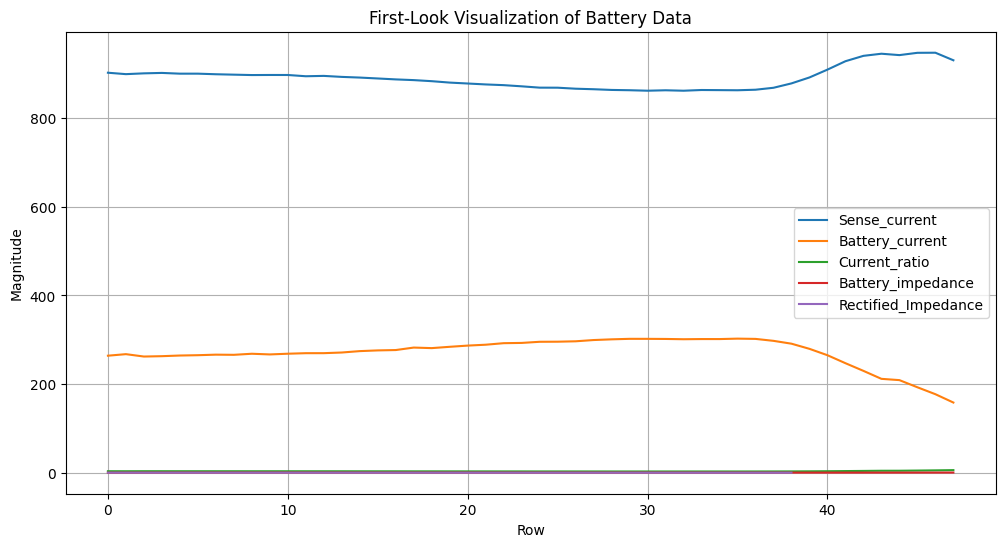

In [21]:
# Day 7 - First-look visualization

import numpy as np
import matplotlib.pyplot as plt

plot_df = sample_df.copy()

# Convert complex-number strings into complex values
for col in plot_df.columns:
    try:
        plot_df[col] = plot_df[col].apply(lambda x: complex(str(x).strip()))
    except:
        pass

# Select complex/numeric columns
plot_columns = []

for col in plot_df.columns:
    if np.iscomplexobj(plot_df[col].values):
        plot_columns.append(col)

print("Columns visualized:")
print(plot_columns)

# Plot magnitude of the first 5 columns
plt.figure(figsize=(12, 6))

for col in plot_columns[:5]:
    magnitude = np.abs(plot_df[col].values)
    plt.plot(magnitude, label=col)

plt.title("First-Look Visualization of Battery Data")
plt.xlabel("Row")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.show()